# VGG16 Transfer Learning Training
This notebook trains a VGG16 model with pretrained ImageNet weights on a custom dataset.

In [9]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/7/segmim_07206.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/7/segmim_07201.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/7/segmim_07213.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/7/segmim_08100.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/7/segmim_07216.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_04979.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_04967.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_04969.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_05010.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_05018.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid/47/segmim_04963.jpg
/kaggle/input/datasets/jd2005/oxford/segmented_d

In [8]:
import zipfile
import os

# Find and extract the zip file
zip_path = '/kaggle/input/datasets/jd2005/oxford'  # adjust if needed

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/kaggle/working/')

print("Extracted! Contents:", os.listdir('/kaggle/working/'))

IsADirectoryError: [Errno 21] Is a directory: '/kaggle/input/datasets/jd2005/oxford'

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-03-13 00:34:49.841726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773362090.046692      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773362090.109431      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773362090.591474      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773362090.591540      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773362090.591544      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [13]:
# Configuration parameters
IMG_SIZE = 224  # VGG16 input size
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001

# Dataset paths - MODIFY THESE PATHS
TRAIN_DIR = '/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/train'
VALID_DIR = '/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/valid'
TEST_DIR = '/kaggle/input/datasets/jd2005/oxford/segmented_dataset_split/test'

# Model save path
MODEL_SAVE_PATH = 'vgg16_model.h5'

In [14]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get number of classes
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {valid_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 5188 images belonging to 103 classes.
Found 1114 images belonging to 103 classes.
Found 1114 images belonging to 103 classes.
Number of classes: 103
Class indices: {'1': 0, '10': 1, '100': 2, '101': 3, '102': 4, '103': 5, '11': 6, '12': 7, '13': 8, '14': 9, '15': 10, '16': 11, '17': 12, '18': 13, '19': 14, '2': 15, '20': 16, '21': 17, '22': 18, '23': 19, '24': 20, '25': 21, '26': 22, '27': 23, '28': 24, '29': 25, '3': 26, '30': 27, '31': 28, '32': 29, '33': 30, '34': 31, '35': 32, '36': 33, '37': 34, '38': 35, '39': 36, '4': 37, '40': 38, '41': 39, '42': 40, '43': 41, '44': 42, '45': 43, '46': 44, '47': 45, '48': 46, '49': 47, '5': 48, '50': 49, '51': 50, '52': 51, '53': 52, '54': 53, '55': 54, '56': 55, '57': 56, '58': 57, '59': 58, '6': 59, '60': 60, '61': 61, '62': 62, '63': 63, '64': 64, '65': 65, '66': 66, '67': 67, '68': 68, '69': 69, '7': 70, '70': 71, '71': 72, '72': 73, '73': 74, '74': 75, '75': 76, '76': 77, '77': 78, '78': 79, '79': 80, '8': 81, '80': 82, '81': 83, '82

In [15]:
# Load VGG16 with pretrained ImageNet weights
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the complete model
model = Model(inputs=base_model.input, outputs=predictions)

print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")
model.summary()

Total layers: 25
Trainable layers: 6


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 103)            │        26,47

 Total params: 27,718,055 (105.74 MB)

 Trainable params: 13,003,367 (49.60 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model compiled successfully!")

Model compiled successfully!


In [17]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [18]:
# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1773362551.067467     187 service.cc:152] XLA service 0x7b4628010380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773362551.067522     187 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773362551.067530     187 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773362551.738181     187 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/163 ━━━━━━━━━━━━━━━━━━━━ 45:54 17s/step - accuracy: 0.0000e+00 - loss: 5.4152 - precision: 0.0000e+00 - recall: 0.0000e+00

...

163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 484ms/step - accuracy: 0.6318 - loss: 1.2946 - precision: 0.8311 - recall: 0.4828 - val_accuracy: 0.7783 - val_loss: 0.8602 - val_precision: 0.8973 - val_recall: 0.6670 - learning_rate: 1.0000e-04
Epoch 79/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.6300 - loss: 1.3167 - precision: 0.8262 - recall: 0.4843
Epoch 79: val_accuracy did not improve from 0.77828

Epoch 79: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 481ms/step - accuracy: 0.6300 - loss: 1.3167 - precision: 0.8262 - recall: 0.4843 - val_accuracy: 0.7747 - val_loss: 0.8692 - val_precision: 0.9065 - val_recall: 0.6526 - learning_rate: 1.0000e-04
Epoch 80/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.6420 - loss: 1.2510 - precision: 0.8385 - recall: 0.5083
Epoch 80: val_accuracy did not improve from 0.77828
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 473ms/step - accuracy: 0.6420 - loss: 1.2510 - precision: 0.8385 - reca

163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 476ms/step - accuracy: 0.6712 - loss: 1.1852 - precision: 0.8378 - recall: 0.5456 - val_accuracy: 0.7873 - val_loss: 0.8207 - val_precision: 0.9125 - val_recall: 0.6741 - learning_rate: 5.0000e-05
Epoch 83/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.6546 - loss: 1.2297 - precision: 0.8348 - recall: 0.5156
Epoch 83: val_accuracy did not improve from 0.78725
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 515ms/step - accuracy: 0.6546 - loss: 1.2296 - precision: 0.8348 - recall: 0.5156 - val_accuracy: 0.7810 - val_loss: 0.8460 - val_precision: 0.9096 - val_recall: 0.6688 - learning_rate: 5.0000e-05
Epoch 84/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6448 - loss: 1.2363 - precision: 0.8313 - recall: 0.5052
Epoch 84: val_accuracy did not improve from 0.78725
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 509ms/step - accuracy: 0.6448 - loss: 1.2364 - precision: 0.8313 - recall: 0.5052 - val_accuracy: 0.7783 - val_loss: 0.8280 - val_precision: 0.9038 -

163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 503ms/step - accuracy: 0.6557 - loss: 1.2458 - precision: 0.8306 - recall: 0.5230 - val_accuracy: 0.7882 - val_loss: 0.8174 - val_precision: 0.9017 - val_recall: 0.6831 - learning_rate: 5.0000e-05
Epoch 90/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.6594 - loss: 1.1913 - precision: 0.8387 - recall: 0.5360
Epoch 90: val_accuracy did not improve from 0.78815
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 506ms/step - accuracy: 0.6594 - loss: 1.1912 - precision: 0.8387 - recall: 0.5360 - val_accuracy: 0.7801 - val_loss: 0.8197 - val_precision: 0.8998 - val_recall: 0.6930 - learning_rate: 5.0000e-05
Epoch 91/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6596 - loss: 1.2073 - precision: 0.8450 - recall: 0.5348
Epoch 91: val_accuracy did not improve from 0.78815
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 483ms/step - accuracy: 0.6596 - loss: 1.2073 - precision: 0.8450 - recall: 0.5348 - val_accuracy: 0.7765 - val_loss: 0.8262 - val_precision: 0.9026 -

163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 528ms/step - accuracy: 0.6645 - loss: 1.1950 - precision: 0.8468 - recall: 0.5298 - val_accuracy: 0.7926 - val_loss: 0.7967 - val_precision: 0.9010 - val_recall: 0.6948 - learning_rate: 2.5000e-05
Epoch 97/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.6743 - loss: 1.1571 - precision: 0.8578 - recall: 0.5470
Epoch 97: val_accuracy did not improve from 0.79264
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 505ms/step - accuracy: 0.6743 - loss: 1.1571 - precision: 0.8578 - recall: 0.5469 - val_accuracy: 0.7882 - val_loss: 0.8092 - val_precision: 0.9038 - val_recall: 0.6912 - learning_rate: 2.5000e-05
Epoch 98/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.6762 - loss: 1.1394 - precision: 0.8639 - recall: 0.5407
Epoch 98: val_accuracy did not improve from 0.79264
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 471ms/step - accuracy: 0.6762 - loss: 1.1394 - precision: 0.8638 - recall: 0.5407 - val_accuracy: 0.7908 - val_loss: 0.7941 - val_precision: 0.9042 -

163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 487ms/step - accuracy: 0.6793 - loss: 1.1198 - precision: 0.8444 - recall: 0.5410 - val_accuracy: 0.7953 - val_loss: 0.8042 - val_precision: 0.9024 - val_recall: 0.6975 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 98.
Training completed!


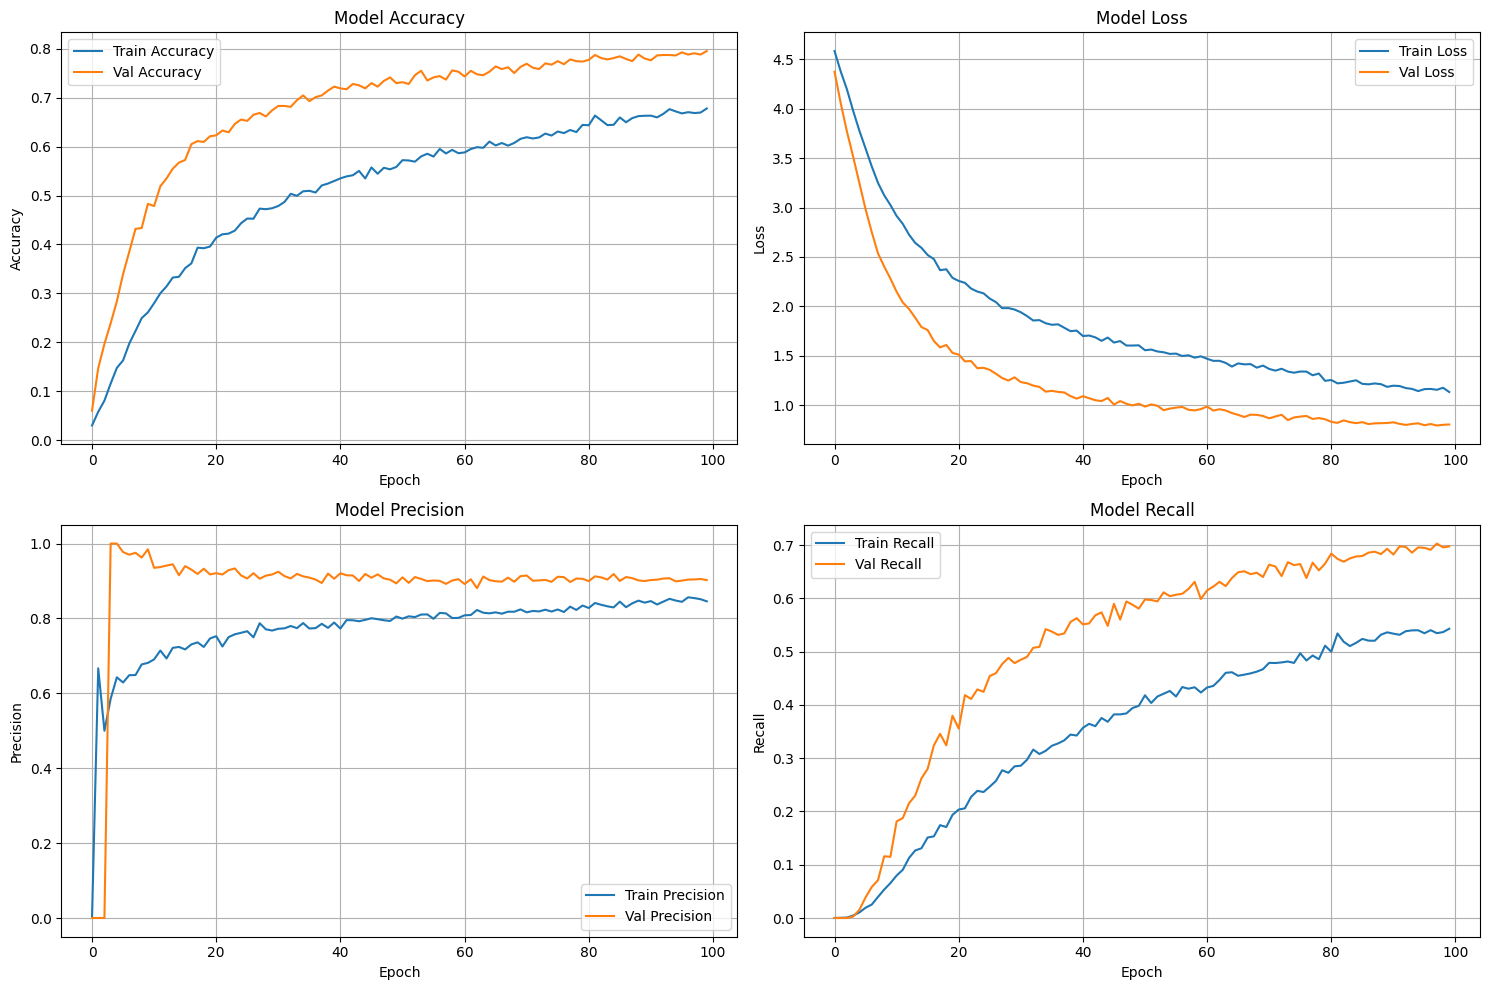

In [19]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('vgg16_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")

Evaluating on test set...
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.7512 - loss: 0.8672 - precision: 0.8702 - recall: 0.6753

Test Results:
Test Loss: 0.8593
Test Accuracy: 0.7657
Test Precision: 0.8880
Test Recall: 0.6903
Test F1-Score: 0.7768


In [21]:
# Generate predictions for confusion matrix
print("Generating predictions...")
test_generator.reset()
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

print(f"\nPrediction shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

Generating predictions...
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step

Prediction shape: (1114, 103)
True labels shape: (1114,)


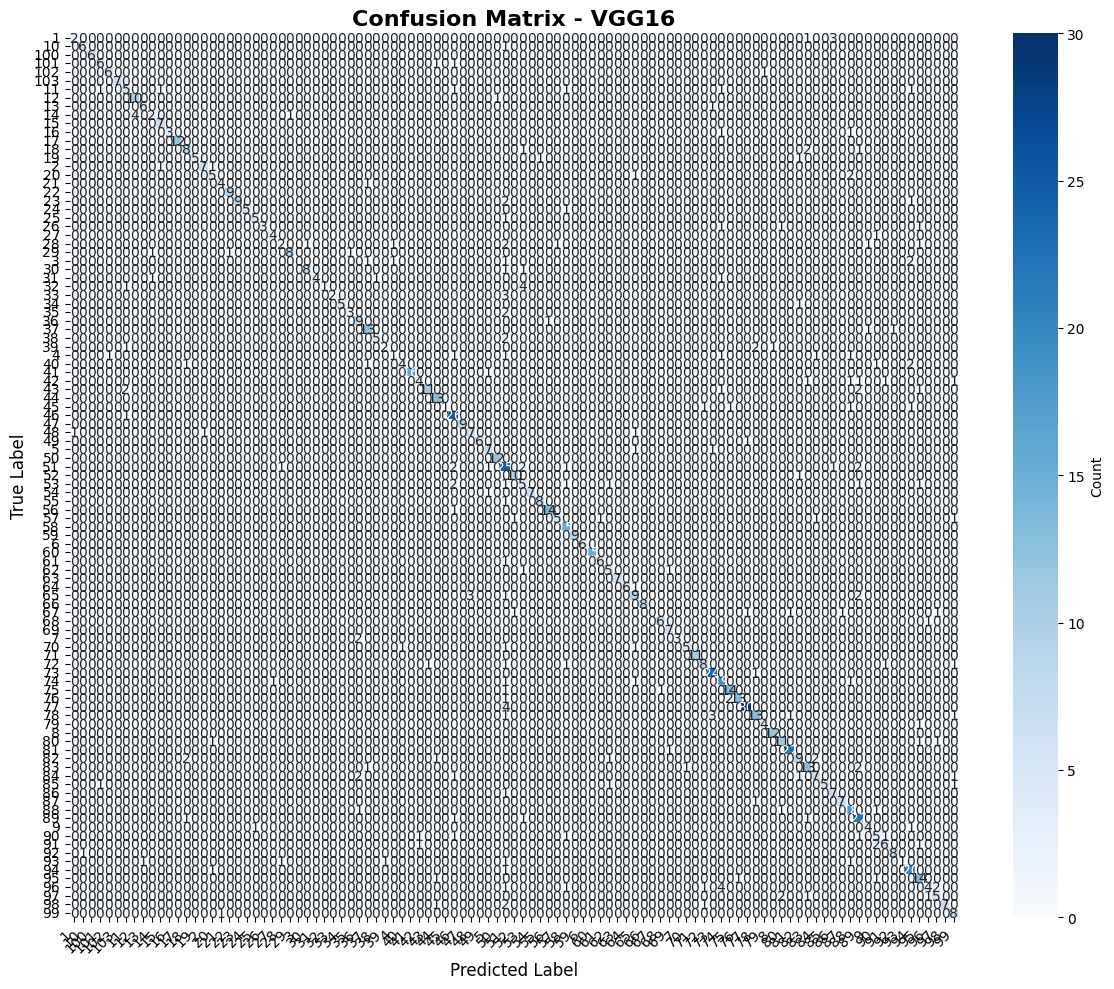

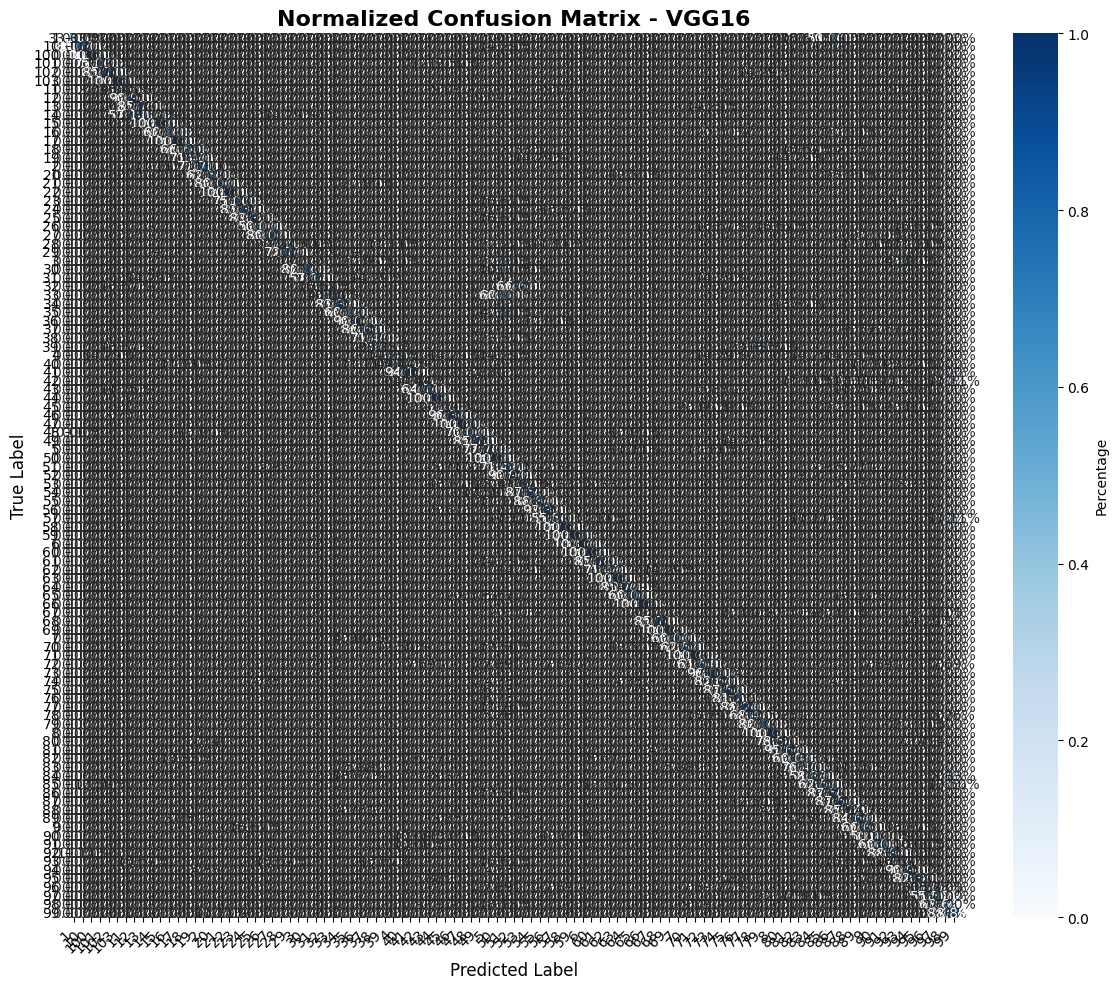

In [22]:
# Create and visualize confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - VGG16', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - VGG16', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Print classification report
print("\nClassification Report:")
print("="*80)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [24]:
# Save the final model
model.save(MODEL_SAVE_PATH)
print(f"\nModel saved successfully to: {MODEL_SAVE_PATH}")

# Save model in .keras format (Keras 3 replacement for SavedModel format)
model.save('vgg16_savedmodel.keras')
print("Model also saved in .keras format: vgg16_savedmodel.keras")

# Save model weights only
model.save_weights('vgg16_weights.weights.h5')
print("Model weights saved: vgg16_weights.weights.h5")


Model saved successfully to: vgg16_model.h5
Model also saved in .keras format: vgg16_savedmodel.keras
Model weights saved: vgg16_weights.weights.h5


Loading model: best_vgg16_model.h5


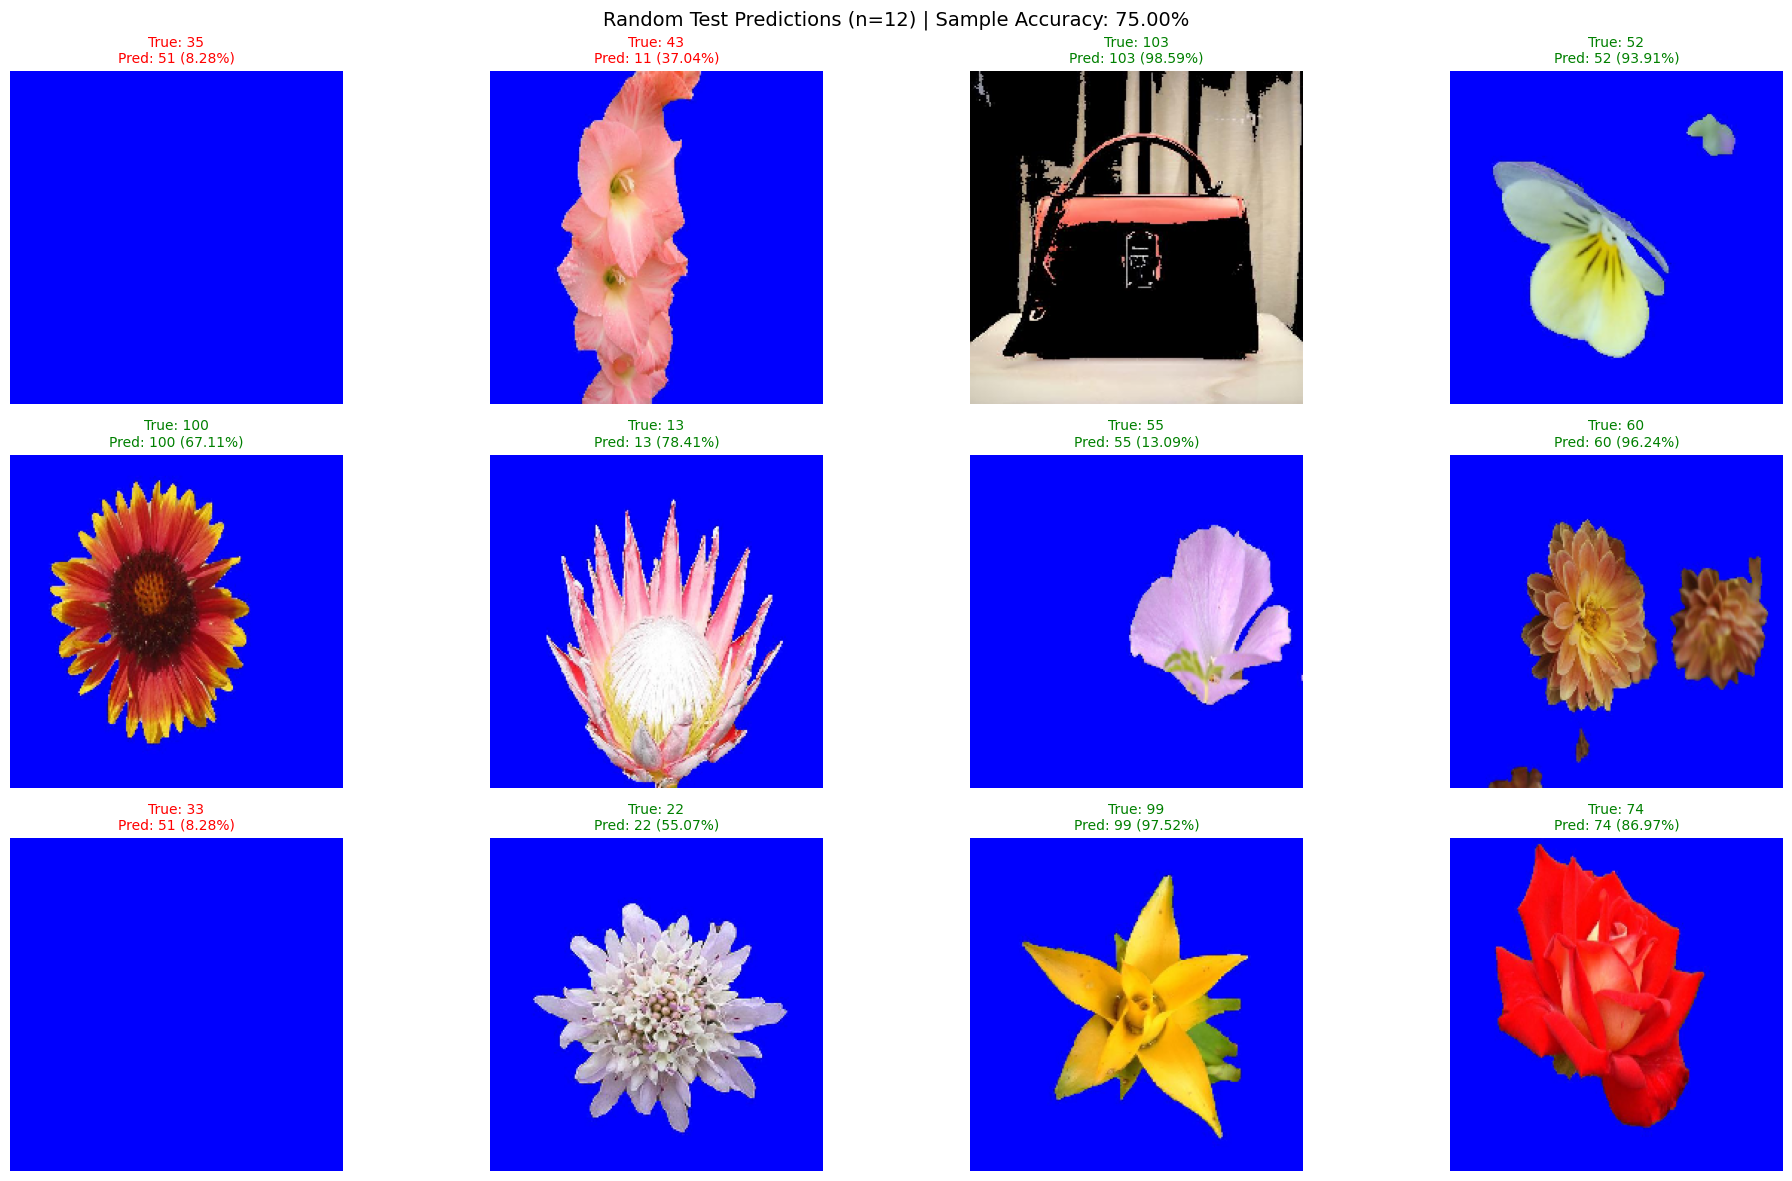

Checked 12 images from: segmented_dataset_split/test
Correct predictions in sample: 9/12 (75.00%)


In [3]:
# Quick inference demo: load saved model and show predictions on random test images
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image

# Paths and settings
IMG_SIZE = 224 if 'IMG_SIZE' not in globals() else IMG_SIZE
TEST_DIR = 'segmented_dataset_split/test' if 'TEST_DIR' not in globals() else TEST_DIR

# Prefer best checkpoint, then final model
candidate_models = ['best_vgg16_model.h5', 'vgg16_model.h5']
model_path = None
for p in candidate_models:
    if os.path.exists(p):
        model_path = p
        break

if model_path is None:
    raise FileNotFoundError('No saved model found. Expected best_vgg16_model.h5 or vgg16_model.h5 in current directory.')

print(f'Loading model: {model_path}')
loaded_model = keras.models.load_model(model_path, compile=False)

if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f'Test directory not found: {TEST_DIR}')

# Build class list from test folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
if len(class_names) == 0:
    raise ValueError(f'No class folders found inside: {TEST_DIR}')

# Collect image paths with true labels
image_records = []
for cls_idx, cls_name in enumerate(class_names):
    cls_dir = os.path.join(TEST_DIR, cls_name)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            image_records.append((os.path.join(cls_dir, fname), cls_idx, cls_name))

if len(image_records) == 0:
    raise ValueError(f'No images found under test directory: {TEST_DIR}')

num_samples = min(12, len(image_records))
samples = random.sample(image_records, num_samples)

# Predict and visualize
cols = 4
rows = int(np.ceil(num_samples / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

correct = 0
for i, (img_path, true_idx, true_name) in enumerate(samples):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    pred = loaded_model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(pred))
    conf = float(pred[pred_idx])

    pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
    is_correct = (pred_idx == true_idx)
    if is_correct:
        correct += 1

    axes[i].imshow(img)
    title_color = 'green' if is_correct else 'red'
    axes[i].set_title(
        f'True: {true_name}\nPred: {pred_name} ({conf:.2%})',
        color=title_color,
        fontsize=10
    )
    axes[i].axis('off')

# Hide any unused subplot axes
for j in range(num_samples, len(axes)):
    axes[j].axis('off')

sample_acc = correct / num_samples
plt.suptitle(f'Random Test Predictions (n={num_samples}) | Sample Accuracy: {sample_acc:.2%}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Checked {num_samples} images from: {TEST_DIR}')
print(f'Correct predictions in sample: {correct}/{num_samples} ({sample_acc:.2%})')

In [ ]:
# Optional: Fine-tuning (unfreeze some layers)
# Uncomment the following cells if you want to fine-tune the model

# # Unfreeze the base model
# base_model.trainable = True

# # Fine-tune from this layer onwards (VGG16 has fewer layers than ResNet)
# fine_tune_at = 15

# # Freeze all layers before fine_tune_at
# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# # Recompile with lower learning rate
# model.compile(
#     optimizer=Adam(learning_rate=LEARNING_RATE/10),
#     loss='categorical_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
# )

# # Continue training
# history_fine = model.fit(
#     train_generator,
#     epochs=20,
#     validation_data=valid_generator,
#     callbacks=callbacks,
#     verbose=1
# )

# # Save fine-tuned model
# model.save('vgg16_finetuned.h5')
# print("Fine-tuned model saved!")

## Summary

This notebook successfully:
1. Loaded and preprocessed the dataset from train/valid/test folders
2. Created a VGG16 model with pretrained ImageNet weights
3. Added custom classification layers
4. Trained the model with data augmentation
5. Evaluated performance on test set
6. Generated confusion matrix visualization
7. Saved the trained model in multiple formats